<a href="https://colab.research.google.com/github/krithimani07-crypto/CODSOFT/blob/main/Movie_Genre_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
#Loading the movie dataset
import pandas as pd
data=pd.read_csv("train_data.txt",sep=":::",engine="python",header=None)
data.head()

,0,1,2,3
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [50]:
#Preview dataset columns and first few rows
data.columns=["ID","Title","Genre","Plot"]
data.head()

,ID,Title,Genre,Plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [14]:
#Text feature extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(X)

In [15]:
#Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
#Prepare and train the Naive Bayes model
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [18]:
#Evaluate model accuracy
from sklearn.metrics import accuracy_score

y_pred = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.5221802084294015


In [20]:
#Initialize Naive Bayes Classifier
from sklearn.naive_bayes import MultinomialNB

# Create the model
model = MultinomialNB()

# Train the model on the training data
model.fit(X_train, y_train)

MultinomialNB()

In [21]:
# Predict a new movie plot
new_plot = ["A young hero discovers his magical powers and saves the kingdom."]
new_plot_vector = vectorizer.transform(new_plot)
predicted_genre = model.predict(new_plot_vector)
print("Predicted Genre:", predicted_genre[0])

Predicted Genre:  drama 


In [34]:
#Load and prepare the movie dataset
import pandas as pd

train_data = pd.read_csv(
    "train_data.txt",
    sep=r"\s*:::\s*",
    engine="python",
    header=None,
    names=["ID", "Title", "Genre", "Plot"]
)

In [35]:
#Feature extraction and model training
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
#Convert text data to TF-IDF features
X = train_data["Plot"]
y = train_data["Genre"]

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_tfidf = vectorizer.fit_transform(X)
#initialize naive bayes classifier
model = MultinomialNB()
model.fit(X_tfidf, y)

MultinomialNB()

In [38]:
#Display TF-IDF vectorizer and model details
print(vectorizer)
print(model)

TfidfVectorizer(max_features=5000, stop_words='english')
MultinomialNB()


In [40]:
#Load and clean the test data
import pandas as pd

# Load test dataset safely, handle extra spaces around ::: and ignore errors
test_data = pd.read_csv(
    "test_data.txt",
    sep=r"\s*:::\s*",  # this handles spaces around :::
    engine="python",
    header=None,
    names=["ID", "Title", "Genre", "Plot"],
    on_bad_lines='skip'  # skip any malformed lines
)

# Ensure Plot column exists
print(test_data.columns)
print(test_data.head())

Index(['ID', 'Title', 'Genre', 'Plot'], dtype='object')
   ID                        Title  \
0   1         Edgar's Lunch (1998)   
1   2     La guerra de papá (1977)   
2   3  Off the Beaten Track (2010)   
3   4       Meu Amigo Hindu (2015)   
4   5            Er nu zhai (1955)   

                                               Genre  Plot  
0  L.R. Brane loves his life - his car, his apart...   NaN  
1  Spain, March 1964: Quico is a very naughty chi...   NaN  
2  One year in the life of Albin and his family o...   NaN  
3  His father has died, he hasn't spoken with his...   NaN  
4  Before he was known internationally as a marti...   NaN  


In [42]:
#Handle missing values in test dataset
test_data["Plot"] = test_data["Plot"].fillna("")
test_data["Plot"] = test_data["Plot"].astype(str)

In [43]:
#Transform test data using trained TF-IDF vectorizer
X_test_data = vectorizer.transform(test_data["Plot"])
predicted_genres = model.predict(X_test_data)
test_data["Predicted_Genre"] = predicted_genres

# View results
test_data[["Title", "Plot", "Predicted_Genre"]].head(10)

# Save predictions
test_data[["ID", "Title", "Predicted_Genre"]].to_csv("test_predictions.csv", index=False)

In [44]:
#Load test predictions for review
import pandas as pd

predictions = pd.read_csv("test_predictions.csv")
predictions.head(10)

,ID,Title,Predicted_Genre
0,1,Edgar's Lunch (1998),drama
1,2,La guerra de papá (1977),drama
2,3,Off the Beaten Track (2010),drama
3,4,Meu Amigo Hindu (2015),drama
4,5,Er nu zhai (1955),drama
5,6,Riddle Room (2016),drama
6,7,L'amica (1969),drama
7,8,Ina Mina Dika (1989),drama
8,9,Equinox Special: Britain's Tornados (2005),drama
9,10,Press (2011),drama


In [45]:
#Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

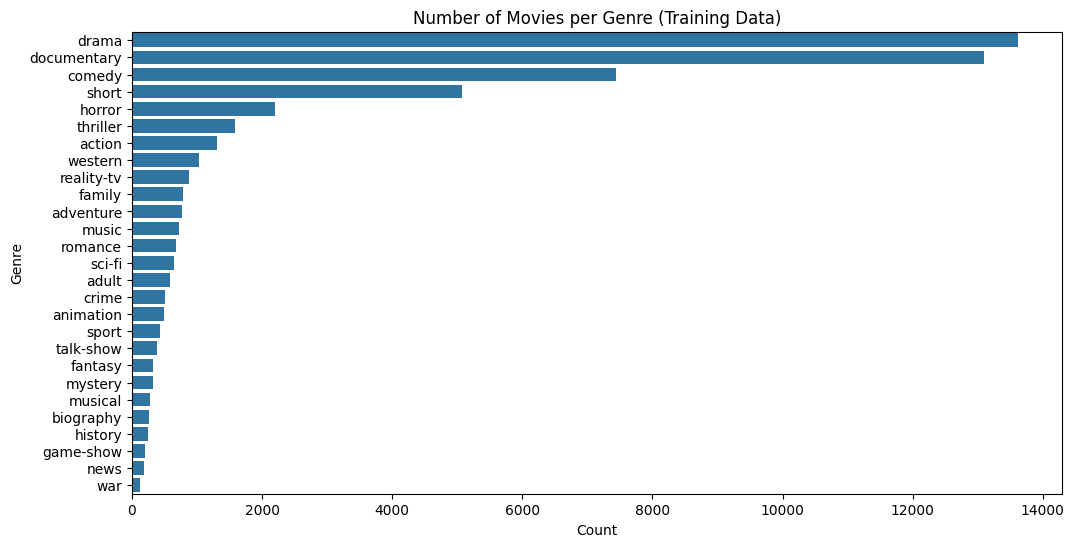

In [46]:
#Generate and customize the plot
plt.figure(figsize=(12,6))
sns.countplot(y="Genre", data=train_data, order=train_data['Genre'].value_counts().index)
plt.title("Number of Movies per Genre (Training Data)")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

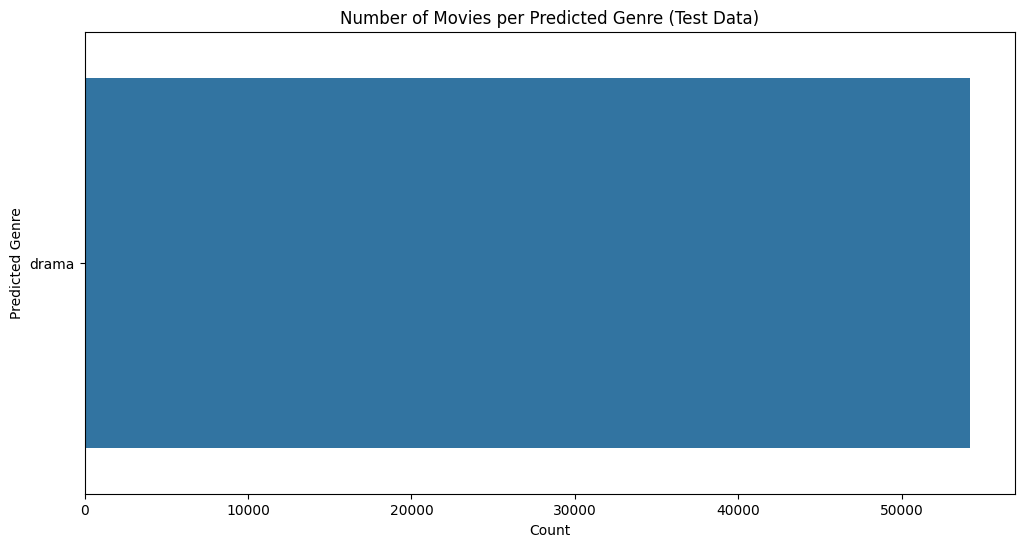

In [47]:
#Visualize movie genre distribution
plt.figure(figsize=(12,6))
sns.countplot(y="Predicted_Genre", data=test_data, order=test_data['Predicted_Genre'].value_counts().index)
plt.title("Number of Movies per Predicted Genre (Test Data)")
plt.xlabel("Count")
plt.ylabel("Predicted Genre")
plt.show()

In [48]:
#Display test data with predicted genres
for genre in test_data["Predicted_Genre"].unique():
    print(f"\nSample plots for genre: {genre}")
    display(test_data[test_data["Predicted_Genre"]==genre][["Title","Plot"]].head(2))


Sample plots for genre: drama


,Title,Plot
0,Edgar's Lunch (1998),
1,La guerra de papá (1977),


In [54]:
# ===============================
# Task Completed: Movie genre classification workflow finished
# ===============================
print("✅ Task Completed: Movie genre classification workflow finished")

✅ Task Completed: Movie genre classification workflow finished
